<a href="https://colab.research.google.com/github/PrabhatYadav9/sales-data-analysis-ml/blob/main/sales_analysis_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**📊 Sales Data Analysis & Machine Learning Project**

In [3]:
# Import libraries
import pandas as pd

In [4]:
import matplotlib.pyplot as plt


In [5]:
df = pd.read_csv("/content/sales.csv.csv")
df.head()


,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [14]:
print("sales's sum",df['Sales'].sum())
print(df['Profit'].sum())


sales's sum 12642905
1467457.2912800002


In [15]:
region_sales = df.groupby('Region')['Sales'].sum()
region_sales

,Sales
Region,
Africa,783776
Canada,66932
Caribbean,324281
Central,2822399
Central Asia,752839
EMEA,806184
East,678834
North,1248192
North Asia,848349


###  Exploratory Data Analysis

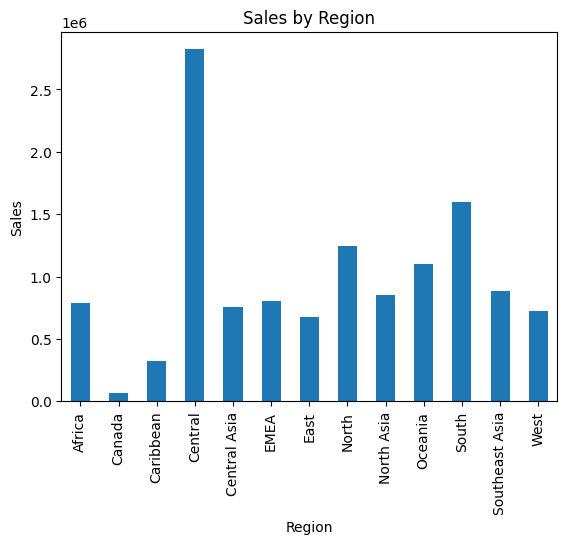

In [16]:
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

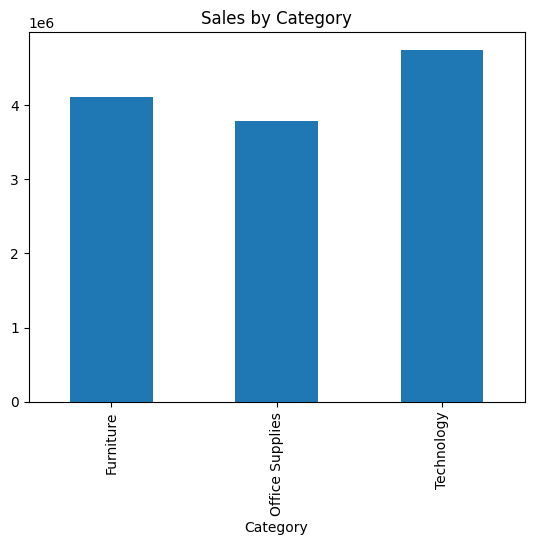

In [17]:
df.groupby('Category')['Sales'].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

Top 5 Products

In [18]:
df.groupby('Product.Name')['Sales'].sum().sort_values(ascending=False).head()

,Sales
Product.Name,
"Apple Smart Phone, Full Size",86936
"Cisco Smart Phone, Full Size",76441
"Motorola Smart Phone, Full Size",73159
"Nokia Smart Phone, Full Size",71904
Canon imageCLASS 2200 Advanced Copier,61600


In [19]:
df.groupby('Year')['Sales'].sum()

,Sales
Year,
2011,2259511
2012,2677493
2013,3405860
2014,4300041


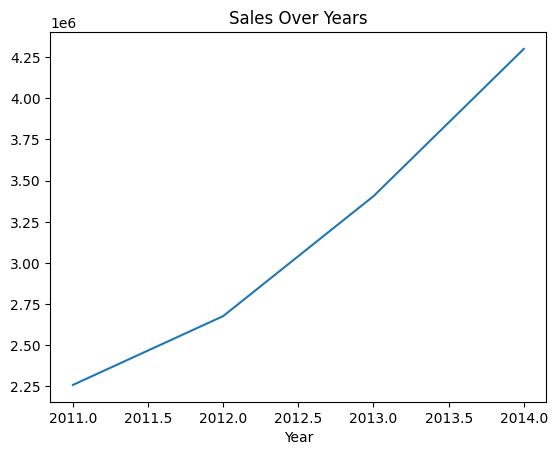

In [20]:
df.groupby('Year')['Sales'].sum().plot(kind='line')
plt.title("Sales Over Years")
plt.show()

# **📊 Key Insights**

• Sales have increased steadily from 2011 to 2014, showing consistent business growth

• Technology category generates the highest sales among all categories, indicating strong demand for tech products

• The Central region performs the best in terms of sales, while regions like Canada and Caribbean show lower performance

• A few products, such as Apple and Cisco smartphones, contribute a significant portion of total sales

• Sales are uneven across different regions, suggesting that some areas have room for improvement


# **Model Building**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [34]:
df_ml = df.copy()

# Convert categorical to numbers
df_ml = df[['Sales', 'Profit', 'Quantity', 'Discount', 'Category', 'Region']]


In [37]:
df_ml.head()



,Sales,Profit,Quantity,Discount,Category,Region
0,19,9.3312,3,0.0,Office Supplies,West
1,19,9.2928,2,0.0,Office Supplies,West
2,21,9.8418,3,0.0,Office Supplies,West
3,111,53.2608,2,0.0,Office Supplies,West
4,6,3.1104,1,0.0,Office Supplies,West


In [38]:
df_ml = pd.get_dummies(df_ml, columns=['Category', 'Region'], drop_first=True)

In [39]:
x = df_ml.drop('Sales', axis=1)
y = df_ml['Sales']

In [40]:
print(x,y)

        Profit  Quantity  Discount  Category_Office Supplies  \
0       9.3312         3       0.0                      True   
1       9.2928         2       0.0                      True   
2       9.8418         3       0.0                      True   
3      53.2608         2       0.0                      True   
4       3.1104         1       0.0                      True   
...        ...       ...       ...                       ...   
51285  22.5732         2       0.2                      True   
51286   3.1584         6       0.2                      True   
51287   4.2804         2       0.2                      True   
51288  33.9300         3       0.2                      True   
51289  51.8238         3       0.2                      True   

       Category_Technology  Region_Canada  Region_Caribbean  Region_Central  \
0                    False          False             False           False   
1                    False          False             False           Fal

In [41]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2)

In [42]:
model = LinearRegression()
model.fit(X_train, Y_train)

LinearRegression()

In [45]:
y_pred = model.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(Y_test, y_pred)

189.82679136330424

In [49]:
df['Sales'].describe()

,Sales
count,51290.000000
mean,246.498440
std,487.567175
min,0.000000
25%,31.000000
50%,85.000000
75%,251.000000
max,22638.000000


In [53]:
#how much closer guesses
import pandas as pd

comparison = pd.DataFrame({
    'Actual': Y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
25718,111,222.304356
14064,66,168.633346
30543,90,270.458136
49053,16,84.016042
4873,32,171.722284


In [52]:
#tell which factor impacting sales most
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.coef_
})

feature_importance.sort_values(by='Importance', ascending=False)

,Feature,Importance
2,Discount,98.531191
1,Quantity,58.210090
8,Region_Central Asia,30.923892
12,Region_North Asia,26.122324
4,Category_Technology,13.716283
5,Region_Canada,13.254785
13,Region_Oceania,11.266525
0,Profit,1.149221
15,Region_Southeast Asia,-1.573609
9,Region_EMEA,-2.827738


#**Improving model**
**by treating outlier**

In [60]:
df_ml = df[['Sales', 'Profit', 'Quantity', 'Discount', 'Shipping.Cost', 'Category', 'Region']]

In [61]:
df_ml.head()


,Sales,Profit,Quantity,Discount,Shipping.Cost,Category,Region
0,19,9.3312,3,0.0,4.37,Office Supplies,West
1,19,9.2928,2,0.0,0.94,Office Supplies,West
2,21,9.8418,3,0.0,1.81,Office Supplies,West
3,111,53.2608,2,0.0,4.59,Office Supplies,West
4,6,3.1104,1,0.0,1.32,Office Supplies,West


In [62]:
df_ml = pd.get_dummies(df_ml, columns=['Category', 'Region'], drop_first=True)

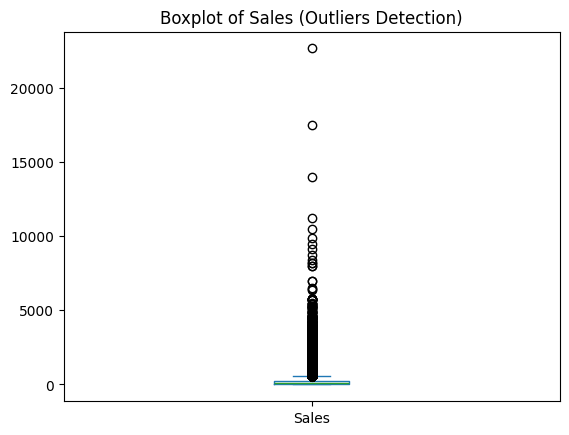

In [63]:
import matplotlib.pyplot as plt

plt.figure()
df['Sales'].plot(kind='box')
plt.title("Boxplot of Sales (Outliers Detection)")
plt.show()

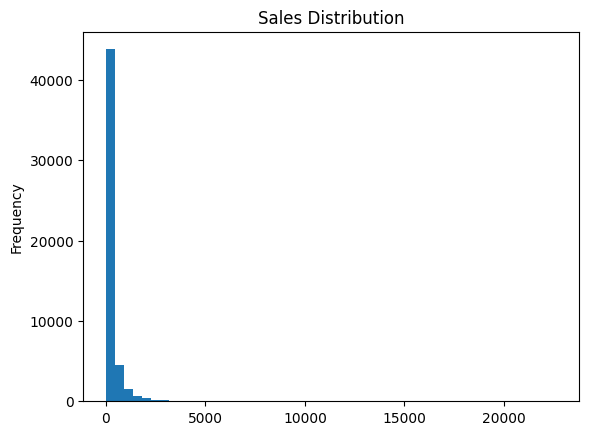

In [64]:
plt.figure()
df['Sales'].plot(kind='hist', bins=50)
plt.title("Sales Distribution")
plt.show()

In [66]:
#removing outlier of sales
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]

len(outliers)
outliers[['Sales']].head()

,Sales
196,1261
201,947
221,1101
226,721
231,726


In [67]:
# capping outliers
df['Sales_capped'] = df['Sales']

df['Sales_capped'] = df['Sales_capped'].clip(lower=lower_bound, upper=upper_bound)

In [68]:
df[['Sales', 'Sales_capped']].describe()

,Sales,Sales_capped
count,51290.000000,51290.000000
mean,246.498440,172.311464
std,487.567175,189.977752
min,0.000000,0.000000
25%,31.000000,31.000000
50%,85.000000,85.000000
75%,251.000000,251.000000
max,22638.000000,581.000000


In [69]:
import numpy as np

df['Sales_log'] = np.log1p(df['Sales'])

In [70]:
df[['Sales', 'Sales_log']].describe()

,Sales,Sales_log
count,51290.000000,51290.000000
mean,246.498440,4.511905
std,487.567175,1.423987
min,0.000000,0.000000
25%,31.000000,3.465736
50%,85.000000,4.454347
75%,251.000000,5.529429
max,22638.000000,10.027429


**MODEL 1: Original Data**

In [81]:
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


In [82]:
X1 = df_ml.drop('Sales', axis=1)
y1 = df_ml['Sales']

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2)

model1 = RandomForestRegressor(n_estimators=100)
model1.fit(X1_train, y1_train)

y1_pred = model1.predict(X1_test)

mae1 = mean_absolute_error(y1_test, y1_pred)
r2_1 = r2_score(y1_test, y1_pred)

**MODEL 2: Capped Data (Improved)**

In [83]:
# Capped
X2 = df_ml.drop('Sales', axis=1)
y2 = df['Sales_capped']

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2)

model2 = RandomForestRegressor(n_estimators=100)
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
r2_2 = r2_score(y2_test, y2_pred)


**MODEL 3: Log Transformed Data (Advanced)**

In [84]:
X3 = df_ml.drop('Sales', axis=1)
y3 = df['Sales_log']

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2)

model3 = RandomForestRegressor(n_estimators=100)
model3.fit(X3_train, y3_train)

y3_pred = model3.predict(X3_test)

# convert back
y3_pred_actual = np.expm1(y3_pred)
y3_test_actual = np.expm1(y3_test)

mae3 = mean_absolute_error(y3_test_actual, y3_pred_actual)
r2_3 = r2_score(y3_test_actual, y3_pred_actual)


**Result comparison**

In [92]:
print( "FINAL RESULTS:\n")

print("Original → MAE:", mae1, "| R2:", r2_1)
print("Capped   → MAE:", mae2, "| R2:", r2_2)
print("Log      → MAE:", mae3, "| R2:", r2_3)

FINAL RESULTS:

Original → MAE: 76.84558036236527 | R2: 0.8134854797183075
Capped   → MAE: 36.41695507571327 | R2: 0.8880234941186733
Log      → MAE: 77.51418697609746 | R2: 0.6651342907861724


In [75]:
from sklearn.metrics import r2_score

r2_1 = r2_score(y_test, y_pred1)

r2_2 = r2_score(y_test, y_pred2)

r2_3 = r2_score(y_test_actual, y_pred3_actual)
print("Original R2:", r2_1)
print("Capped R2:", r2_2)
print("Log R2:", r2_3)

Original R2: -129917.1503562974
Capped R2: -30377.144275111932
Log R2: 0.8049999693713983


In [93]:
print("Final Model Comparison:\n")

print(f"Original model gave an error of {mae1:.2f} with R² score {r2_1:.2f}")
print(f"Capped model improved the results with error {mae2:.2f} and R² {r2_2:.2f}")
print(f"Log transformed model resulted in error {mae3:.2f} with R² {r2_3:.2f}")

Final Model Comparison:

Original model gave an error of 76.85 with R² score 0.81
Capped model improved the results with error 36.42 and R² 0.89
Log transformed model resulted in error 77.51 with R² 0.67


## **Final Conclusion**

• The dataset contained significant outliers which affected model performance

• Applying IQR-based capping helped stabilize the data and improved prediction accuracy

• Among all approaches, the capped data model performed the best with the lowest error and highest R² score

• This project highlights the importance of proper data preprocessing in machine learning

• Overall, Random Forest proved to be an effective model for this regression problem
